# Exploratory Data Analysis (EDA) — Cars Dataset

**Goal:** Understand the structure, quality, and key patterns in the Cars dataset before any modeling — checking its shape, data types, missing values, and the distribution/relationships of key features like price, mileage, and horsepower.

**Dataset:** `cars.csv` — 428 cars with 15 attributes each: Make, Model, Type, Origin, DriveTrain, MSRP (price), Invoice, EngineSize, Cylinders, Horsepower, MPG_City, MPG_Highway, Weight, Wheelbase, Length.

## 1. Imports & Setup

In [1]:
# Core libraries for data handling, numerical work, and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = [10, 5]

## 2. Load the Data

We treat common placeholder strings (`"NA"`, `"?"`, blank space, etc.) as missing values right at load time, so we only need to read the file once.

In [2]:
cars_df = pd.read_csv(
    "https://raw.githubusercontent.com/sassoftware/sas-viya-programming/master/data/cars.csv",
    na_values=['NA', 'Na', '?', 'null', ' ']
)

print(f'Dataset loaded successfully: {cars_df.shape[0]} rows, {cars_df.shape[1]} columns')

Dataset loaded successfully: 428 rows, 15 columns


In [3]:
cars_df.shape

(428, 15)

## 3. First Look at the Data

In [4]:
cars_df.head()

,Make,Model,Type,Origin,DriveTrain,MSRP,Invoice,EngineSize,Cylinders,Horsepower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,MDX,SUV,Asia,All,36945.0,33337.0,3.5,6.0,265.0,17.0,23.0,4451.0,106.0,189.0
1,Acura,RSX Type S 2dr,Sedan,Asia,Front,23820.0,21761.0,2.0,4.0,200.0,24.0,31.0,2778.0,101.0,172.0
2,Acura,TSX 4dr,Sedan,Asia,Front,26990.0,24647.0,2.4,4.0,200.0,22.0,29.0,3230.0,105.0,183.0
3,Acura,TL 4dr,Sedan,Asia,Front,33195.0,30299.0,3.2,6.0,270.0,20.0,28.0,3575.0,108.0,186.0
4,Acura,3.5 RL 4dr,Sedan,Asia,Front,43755.0,39014.0,3.5,6.0,225.0,18.0,24.0,3880.0,115.0,197.0


In [5]:
cars_df.tail()

,Make,Model,Type,Origin,DriveTrain,MSRP,Invoice,EngineSize,Cylinders,Horsepower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
423,Volvo,C70 LPT convertible 2dr,Sedan,Europe,Front,40565.0,38203.0,2.4,5.0,197.0,21.0,28.0,3450.0,105.0,186.0
424,Volvo,C70 HPT convertible 2dr,Sedan,Europe,Front,42565.0,40083.0,2.3,5.0,242.0,20.0,26.0,3450.0,105.0,186.0
425,Volvo,S80 T6 4dr,Sedan,Europe,Front,45210.0,42573.0,2.9,6.0,268.0,19.0,26.0,3653.0,110.0,190.0
426,Volvo,V40,Wagon,Europe,Front,26135.0,24641.0,1.9,4.0,170.0,22.0,29.0,2822.0,101.0,180.0
427,Volvo,XC70,Wagon,Europe,All,35145.0,33112.0,2.5,5.0,208.0,20.0,27.0,3823.0,109.0,186.0


In [6]:
# Column names, data types, and non-null counts in one summary
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Make         428 non-null    object 
 1   Model        428 non-null    object 
 2   Type         428 non-null    object 
 3   Origin       428 non-null    object 
 4   DriveTrain   428 non-null    object 
 5   MSRP         428 non-null    float64
 6   Invoice      428 non-null    float64
 7   EngineSize   428 non-null    float64
 8   Cylinders    426 non-null    float64
 9   Horsepower   428 non-null    float64
 10  MPG_City     428 non-null    float64
 11  MPG_Highway  428 non-null    float64
 12  Weight       428 non-null    float64
 13  Wheelbase    428 non-null    float64
 14  Length       428 non-null    float64
dtypes: float64(10), object(5)
memory usage: 50.3+ KB


### Rename a few columns for clarity
`MSRP` becomes `MRP`, and the MPG columns become explicit `Mileage_*` names.

In [7]:
cars_df.rename(columns={
    'MSRP': 'MRP',
    'MPG_City': 'Mileage_City',
    'MPG_Highway': 'Mileage_Highway'
}, inplace=True)

#cars_df.columns.tolist()

## 4. Data Cleaning

### 4.1 Missing values
Check how many values are missing in each column, and as a percentage of the total.

In [8]:
missing = cars_df.isnull().sum()
missing_pct = (missing / len(cars_df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing %
Cylinders,2,0.47


In [9]:
missing_pct

Make               0.00
Model              0.00
Type               0.00
Origin             0.00
DriveTrain         0.00
MRP                0.00
Invoice            0.00
EngineSize         0.00
Cylinders          0.47
Horsepower         0.00
Mileage_City       0.00
Mileage_Highway    0.00
Weight             0.00
Wheelbase          0.00
Length             0.00
dtype: float64

In [10]:
missing

Make               0
Model              0
Type               0
Origin             0
DriveTrain         0
MRP                0
Invoice            0
EngineSize         0
Cylinders          2
Horsepower         0
Mileage_City       0
Mileage_Highway    0
Weight             0
Wheelbase          0
Length             0
dtype: int64

In [11]:
cars_df.describe()

,MRP,Invoice,EngineSize,Cylinders,Horsepower,Mileage_City,Mileage_Highway,Weight,Wheelbase,Length
count,428.000000,428.000000,428.000000,426.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000
mean,32774.855140,30014.700935,3.196729,5.807512,215.885514,20.060748,26.843458,3577.953271,108.154206,186.362150
std,19431.716674,17642.117750,1.108595,1.558443,71.836032,5.238218,5.741201,758.983215,8.311813,14.357991
min,10280.000000,9875.000000,1.300000,3.000000,73.000000,10.000000,12.000000,1850.000000,89.000000,143.000000
25%,20334.250000,18866.000000,2.375000,4.000000,165.000000,17.000000,24.000000,3104.000000,103.000000,178.000000
50%,27635.000000,25294.500000,3.000000,6.000000,210.000000,19.000000,26.000000,3474.500000,107.000000,187.000000
75%,39205.000000,35710.250000,3.900000,6.000000,255.000000,21.250000,29.000000,3977.750000,112.000000,194.000000
max,192465.000000,173560.000000,8.300000,12.000000,500.000000,60.000000,66.000000,7190.000000,144.000000,238.000000


Only `Cylinders` has missing values. Since it's a numeric column, we fill the gaps with the **median** (robust to outliers), then convert it to an integer type.

In [12]:
median_cylinders = cars_df['Cylinders'].median()
cars_df['Cylinders'] = cars_df['Cylinders'].fillna(median_cylinders)
cars_df['Cylinders'] = cars_df['Cylinders'].astype(int)

print(f'Missing Cylinders filled with median value: {median_cylinders}')
print(f'Remaining missing values overall: {cars_df.isnull().sum().sum()}')

Missing Cylinders filled with median value: 6.0
Remaining missing values overall: 0


In [13]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Make             428 non-null    object 
 1   Model            428 non-null    object 
 2   Type             428 non-null    object 
 3   Origin           428 non-null    object 
 4   DriveTrain       428 non-null    object 
 5   MRP              428 non-null    float64
 6   Invoice          428 non-null    float64
 7   EngineSize       428 non-null    float64
 8   Cylinders        428 non-null    int32  
 9   Horsepower       428 non-null    float64
 10  Mileage_City     428 non-null    float64
 11  Mileage_Highway  428 non-null    float64
 12  Weight           428 non-null    float64
 13  Wheelbase        428 non-null    float64
 14  Length           428 non-null    float64
dtypes: float64(9), int32(1), object(5)
memory usage: 48.6+ KB


### 4.2 Duplicate rows

In [14]:
duplicate_count = cars_df.duplicated().sum()
cars_df.drop_duplicates(inplace=True)

print(f'Duplicate rows found and removed: {duplicate_count}')
print(f'Shape after cleaning: {cars_df.shape}')

Duplicate rows found and removed: 0
Shape after cleaning: (428, 15)


## 5. Descriptive Statistics

Quick summary of the numeric columns — count, mean, std, min/max, and quartiles. This helps catch obviously wrong values at a glance.

In [15]:
cars_df.describe()

,MRP,Invoice,EngineSize,Cylinders,Horsepower,Mileage_City,Mileage_Highway,Weight,Wheelbase,Length
count,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000,428.000000
mean,32774.855140,30014.700935,3.196729,5.808411,215.885514,20.060748,26.843458,3577.953271,108.154206,186.362150
std,19431.716674,17642.117750,1.108595,1.554844,71.836032,5.238218,5.741201,758.983215,8.311813,14.357991
min,10280.000000,9875.000000,1.300000,3.000000,73.000000,10.000000,12.000000,1850.000000,89.000000,143.000000
25%,20334.250000,18866.000000,2.375000,4.000000,165.000000,17.000000,24.000000,3104.000000,103.000000,178.000000
50%,27635.000000,25294.500000,3.000000,6.000000,210.000000,19.000000,26.000000,3474.500000,107.000000,187.000000
75%,39205.000000,35710.250000,3.900000,6.000000,255.000000,21.250000,29.000000,3977.750000,112.000000,194.000000
max,192465.000000,173560.000000,8.300000,12.000000,500.000000,60.000000,66.000000,7190.000000,144.000000,238.000000


## 6. Univariate Analysis — Categorical Columns

Looking at one categorical column at a time: how many cars fall into each category?

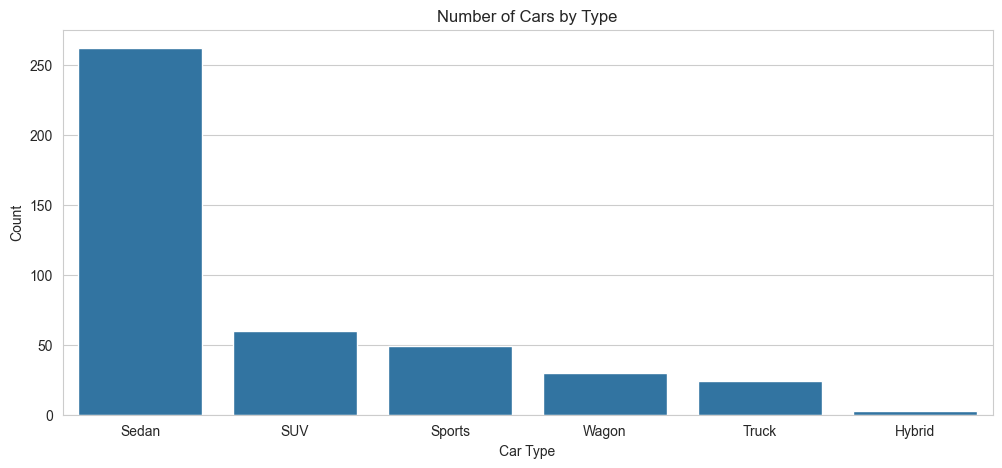

In [ ]:
# Number of cars by Type
plt.figure(figsize=(12, 5))
sns.countplot(data=cars_df, x='Type', order=cars_df['Type'].value_counts().index)
plt.title('Number of Cars by Type')
plt.xlabel('Car Type')
plt.ylabel('Count')
plt.show()

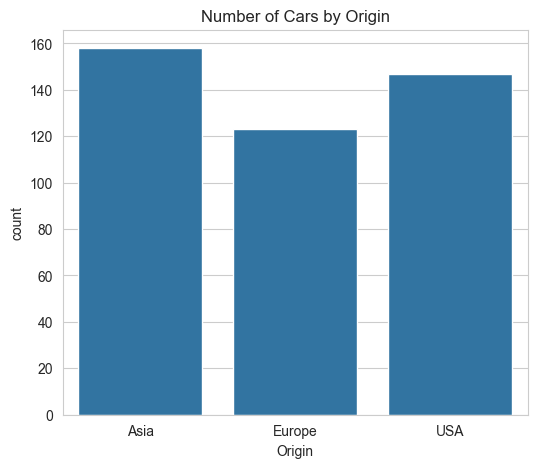

In [17]:
# Number of cars by Origin
plt.figure(figsize=(6, 5))
sns.countplot(data=cars_df, x='Origin')
plt.title('Number of Cars by Origin')
plt.show()

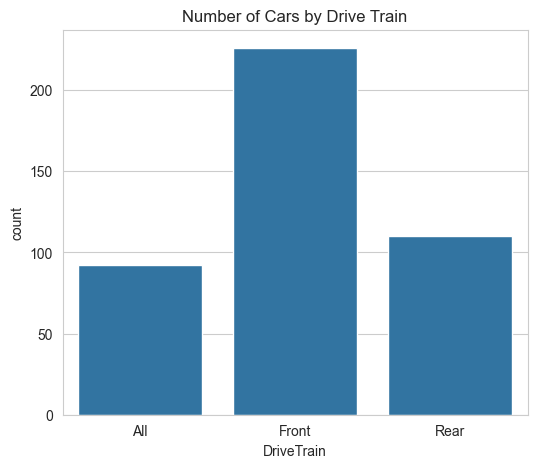

In [18]:
# Number of cars by DriveTrain
plt.figure(figsize=(6, 5))
sns.countplot(data=cars_df, x='DriveTrain')
plt.title('Number of Cars by Drive Train')
plt.show()

## 7. Univariate Analysis — Numerical Columns

Looking at the distribution (spread and shape) of key numeric features.

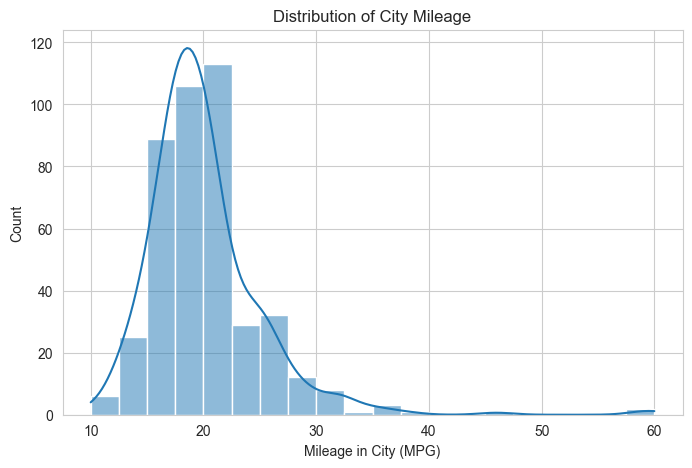

In [29]:
# Distribution of city mileage
plt.figure(figsize=(8, 5))
sns.histplot(cars_df['Mileage_City'], bins=20, kde=True)
plt.title('Distribution of City Mileage')
plt.xlabel('Mileage in City (MPG)')
plt.show()

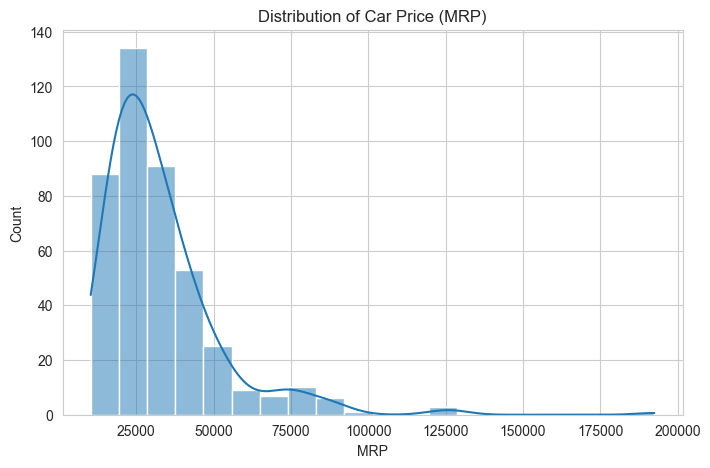

In [20]:
# Distribution of price (MRP)
plt.figure(figsize=(8, 5))
sns.histplot(cars_df['MRP'], bins=20, kde=True)
plt.title('Distribution of Car Price (MRP)')
plt.xlabel('MRP')
plt.show()

## 8. Bivariate & Multivariate Analysis

Now we look at relationships **between** variables — does price relate to horsepower? Does mileage differ by drivetrain?

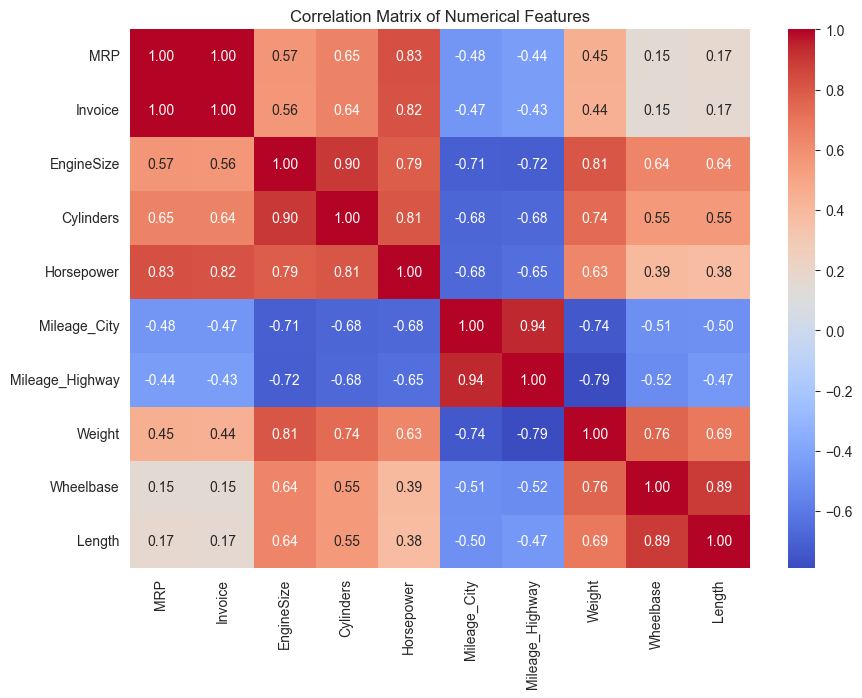

In [21]:
# Correlation matrix of numeric features
numerical_df = cars_df.select_dtypes(include=np.number)
plt.figure(figsize=(10, 7))
sns.heatmap(numerical_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

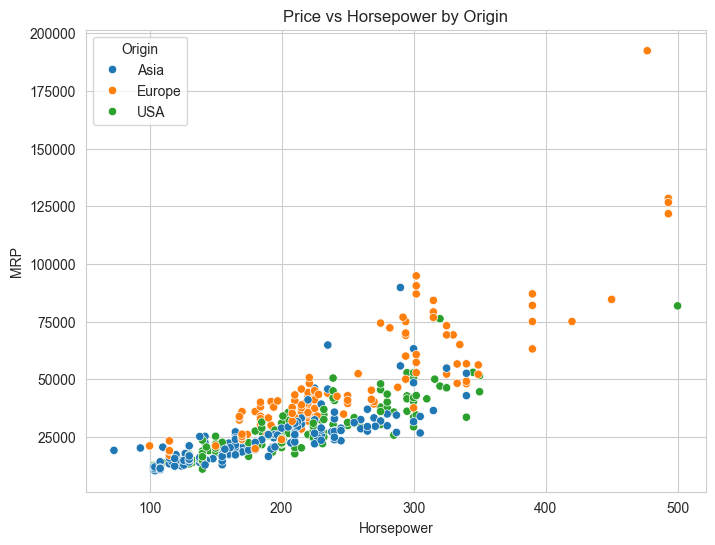

In [22]:
# Price vs Horsepower, colored by Origin
plt.figure(figsize=(8, 6))
sns.scatterplot(data=cars_df, x='Horsepower', y='MRP', hue='Origin')
plt.title('Price vs Horsepower by Origin')
plt.show()

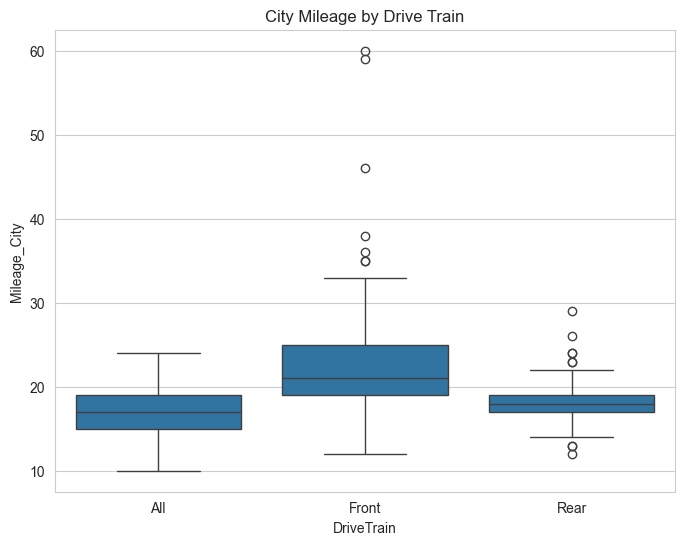

In [23]:
# City mileage by drivetrain
plt.figure(figsize=(8, 6))
sns.boxplot(data=cars_df, x='DriveTrain', y='Mileage_City')
plt.title('City Mileage by Drive Train')
plt.show()

## 9. Outlier Detection

We use the **IQR (Interquartile Range) method**: values below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` are flagged as potential outliers. We inspect them here rather than removing them — that decision depends on the goal of a later modeling step, which is outside the scope of EDA.

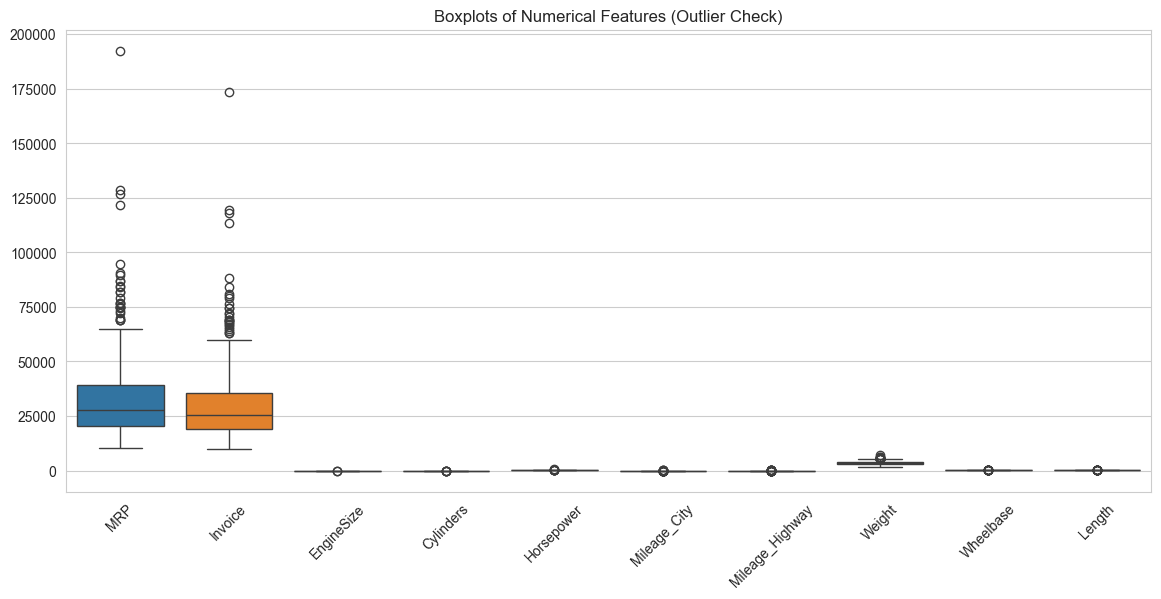

In [24]:
# Boxplots make outliers easy to spot visually
plt.figure(figsize=(14, 6))
sns.boxplot(data=numerical_df)
plt.xticks(rotation=45)
plt.title('Boxplots of Numerical Features (Outlier Check)')
plt.show()

In [25]:
# Count potential outliers per column using the IQR rule
Q1 = numerical_df.quantile(0.25)
Q3 = numerical_df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = ((numerical_df < lower_bound) | (numerical_df > upper_bound)).sum()
outlier_counts[outlier_counts > 0].sort_values(ascending=False)

Mileage_City       30
MRP                27
Invoice            27
Mileage_Highway    24
Wheelbase          19
Length             16
Weight             14
Horsepower          7
Cylinders           5
EngineSize          2
dtype: int64

## 10. Key Takeaways

- The dataset has **428 cars** across **15 attributes**, with only `Cylinders` having missing values (filled with the median) and no duplicate rows.
- **Car types and origins are imbalanced** — some categories (e.g. certain `Type` and `DriveTrain` values) are far more common than others.
- **Price (MRP) and city mileage are right-skewed**, with a handful of very expensive / very low-mileage cars showing up as outliers.
- **Horsepower and price are positively correlated** — more powerful cars tend to cost more.
- Several numeric columns (`MRP`, `Invoice`, `Horsepower`, `Weight`) show noticeable outliers per the IQR check.